# When and Where Do Retail Promotions Work Best?

A business case study using Rossmann daily store sales.

**Questions.** How does the promotion-associated sales difference vary by weekday, store format, assortment and competitive proximity? Does customer traffic explain the sales difference?

The analysis uses matched descriptive comparisons and a small forecasting benchmark. It estimates associations, not a causal treatment effect. The target is sales turnover, not profit. Each observation is a store-day, not a transaction.

Run the cells in order. Local: put `train.csv` and `store.csv` in `data/`, or set `ROSSMANN_DATA_DIR`. Kaggle: attach the Rossmann competition data. This notebook discovers the two files automatically. No internet or external code is needed during execution.

In [1]:
from pathlib import Path
import os, json, hashlib, warnings
os.environ.setdefault('OMP_NUM_THREADS', '4')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '4')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
warnings.filterwarnings('ignore', category=FutureWarning)
SEED = 42
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if (ROOT / 'src').exists():
    OUT = ROOT
else:
    OUT = Path('/kaggle/working') if Path('/kaggle/working').exists() else ROOT
for folder in ['results', 'figures']:
    (OUT / folder).mkdir(exist_ok=True, parents=True)
search = [Path(os.environ['ROSSMANN_DATA_DIR'])] if os.environ.get('ROSSMANN_DATA_DIR') else []
search += [ROOT / 'data', ROOT.parent / 'upload', Path('/kaggle/input')]
DATA = next((p for base in search if base.exists() for p in [base, *base.rglob('train.csv')] if (p if p.is_dir() else p.parent).joinpath('train.csv').exists() and (p if p.is_dir() else p.parent).joinpath('store.csv').exists()), None)
if DATA is None:
    raise FileNotFoundError('Place train.csv and store.csv together in data/ or set ROSSMANN_DATA_DIR.')
DATA = DATA if DATA.is_dir() else DATA.parent
plt.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 180, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = ['#20384d', '#168b89', '#cf874c']
def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / 'figures' / (name + '.png'), bbox_inches='tight')
    plt.show()
def table(frame, name):
    frame.to_csv(OUT / 'results' / (name + '.csv'), index=False)
    print(frame.round(3).to_string(index=False))

## 1. Check the data before interpreting it

`train.csv` contains outcomes. `store.csv` contains one row per store. The competition test file has no observed sales, so it cannot evaluate these research questions; it and the submission template are left unused. A many-to-one join must preserve the row count.

In [2]:
train = pd.read_csv(DATA / 'train.csv', dtype={'StateHoliday': str}, parse_dates=['Date'])
stores = pd.read_csv(DATA / 'store.csv')
assert not train.duplicated(['Store', 'Date']).any()
assert stores['Store'].is_unique
full = train.merge(stores, on='Store', how='left', validate='many_to_one', indicator=True)
assert len(full) == len(train) and full['_merge'].eq('both').all()
full = full.drop(columns='_merge')
audit = {'rows': len(train), 'stores': train.Store.nunique(), 'start': str(train.Date.min().date()), 'end': str(train.Date.max().date()), 'closed_rows': int(train.Open.eq(0).sum()), 'open_zero_sales': int((train.Open.eq(1) & train.Sales.eq(0)).sum()), 'duplicates': 0}
print(json.dumps(audit, indent=2))
table(stores.isna().sum().rename('missing').rename_axis('field').reset_index(), 'store_missing')
table(train.groupby(['Open', 'Promo']).agg(rows=('Sales', 'size'), mean_sales=('Sales', 'mean')).reset_index(), 'open_promo_audit')
manifest = {f: {'bytes': (DATA / f).stat().st_size, 'sha256': hashlib.sha256((DATA / f).read_bytes()).hexdigest()} for f in ['train.csv', 'store.csv']}
(OUT / 'results' / 'input_manifest.json').write_text(json.dumps(manifest, indent=2))

{
  "rows": 1017209,
  "stores": 1115,
  "start": "2013-01-01",
  "end": "2015-07-31",
  "closed_rows": 172817,
  "open_zero_sales": 54,
  "duplicates": 0
}
                    field  missing
                    Store        0
                StoreType        0
               Assortment        0
      CompetitionDistance        3
CompetitionOpenSinceMonth      354
 CompetitionOpenSinceYear      354
                   Promo2        0
          Promo2SinceWeek      544
          Promo2SinceYear      544
            PromoInterval      544
 Open  Promo   rows  mean_sales
    0      0 161633       0.000
    0      1  11184       0.000
    1      0 467496    5929.408
    1      1 376896    8228.281


## 2. Define the comparison population

Keep open stores, positive sales and customer counts, Monday to Friday, and non-public-holiday dates. This gives all three outcomes the same population and avoids asking the model to extrapolate a weekend promotion never seen in training.

School holidays remain in the data. Missing competition metadata stay explicit. Missing Promo2 dates for non-participating stores are structural, not errors. `CompetitionDistance` is a proximity proxy; it does not measure competitor prices, quality or market share.

 DayOfWeek  count   sum  mean
         1 144730 77760 0.537
         2 145664 77580 0.533
         3 145665 77580 0.533
         4 145845 77580 0.532
         5 145845 77580 0.532
         6 144730     0 0.000
         7 144730     0 0.000
Weekday dates with a single chain-wide Promo value: 674 of 674
Analysis rows: 695791 | stores: 1115
 Promo   rows    Sales  Customers  SpendPerCustomer
     0 319352 5925.310    704.041             8.829
     1 376439 8227.469    843.954            10.181


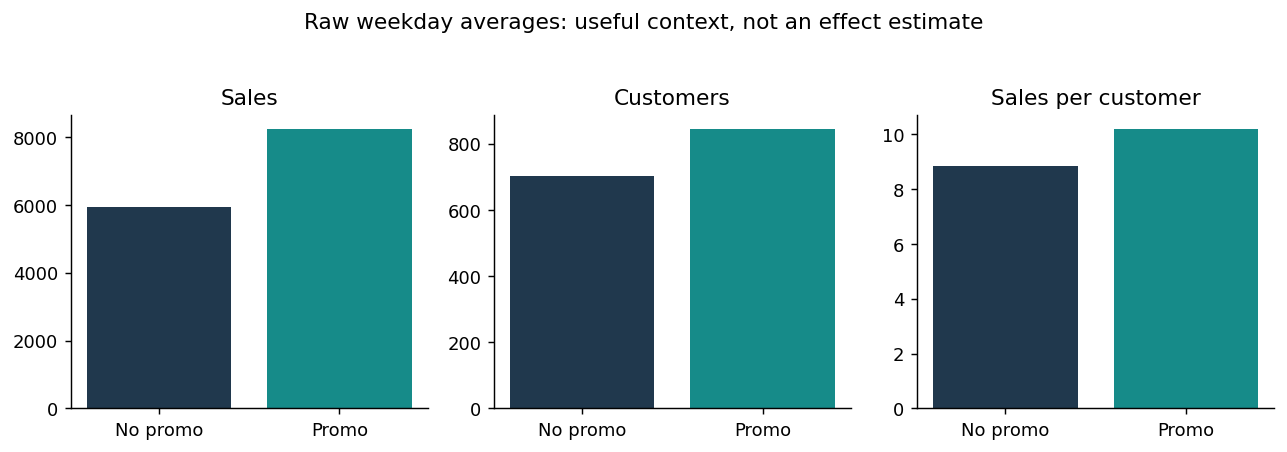

In [3]:
daily_support = train.groupby('DayOfWeek').Promo.agg(['count', 'sum', 'mean']).reset_index()
table(daily_support, 'promotion_support')
by_date = train.loc[train.DayOfWeek.le(5)].groupby('Date').Promo.nunique()
print('Weekday dates with a single chain-wide Promo value:', int(by_date.eq(1).sum()), 'of', len(by_date))
d = full.loc[full.Open.eq(1) & full.Sales.gt(0) & full.Customers.gt(0) & full.DayOfWeek.le(5) & full.StateHoliday.eq('0')].copy()
d['Year'] = d.Date.dt.year
d['Month'] = d.Date.dt.month
d['YearMonth'] = d.Date.dt.to_period('M').astype(str)
d['SpendPerCustomer'] = d.Sales / d.Customers
d['CompetitionBand'] = pd.cut(d.CompetitionDistance, [-np.inf, 500, 2000, 5000, np.inf], labels=['<=500 m', '501-2,000 m', '2,001-5,000 m', '>5,000 m']).astype('object').fillna('Unknown')
audit['analysis_rows'] = len(d)
print('Analysis rows:', len(d), '| stores:', d.Store.nunique())
raw = d.groupby('Promo').agg(rows=('Sales', 'size'), Sales=('Sales', 'mean'), Customers=('Customers', 'mean'), SpendPerCustomer=('SpendPerCustomer', 'mean')).reset_index()
table(raw, 'raw_comparison')
fig, axes = plt.subplots(1, 3, figsize=(10, 3.3))
for ax, outcome in zip(axes, ['Sales', 'Customers', 'SpendPerCustomer']):
    ax.bar(['No promo', 'Promo'], raw[outcome], color=COLORS[:2])
    ax.set_title(outcome.replace('SpendPerCustomer', 'Sales per customer'))
fig.suptitle('Raw weekday averages: useful context, not an effect estimate', y=1.04)
savefig('01_raw_comparison')

## 3. Match comparable calendar conditions

For each store x year-month x weekday, calculate the mean outcome on promotion and non-promotion days. Require at least two observations of each status. The stratum difference is:

`100 * (mean_promo / mean_no_promo - 1)`.

Average these percentage differences equally over eligible strata within a store, then equally over stores. This avoids giving large or better-observed stores most of the weight. It holds store identity, month and weekday fixed; it does not control exact-date demand shocks. Sales-per-customer is the mean of daily ratios and should not be read as basket size per transaction.

Intervals below resample whole stores 500 times. They describe variation across stores conditional on the observed calendar, not causal uncertainty or uncertainty about future dates. Chain-wide promotion timing makes that distinction material.

In [4]:
OUTCOMES = ['Sales', 'Customers', 'SpendPerCustomer']
keys = ['Store', 'YearMonth', 'DayOfWeek']
g = d.groupby(keys + ['Promo'])[OUTCOMES].mean().unstack('Promo')
n = d.groupby(keys + ['Promo']).size().unstack('Promo', fill_value=0)
valid = n[0].ge(2) & n[1].ge(2)
pairs = g.loc[valid].copy()
matched = pairs.index.to_frame(index=False)
for y in OUTCOMES:
    matched[y + 'LiftPct'] = (100 * (pairs[(y, 1)] / pairs[(y, 0)] - 1)).to_numpy()
matched = matched.merge(stores, on='Store', validate='many_to_one')
matched['Year'] = matched.YearMonth.str[:4].astype(int)
matched['Month'] = matched.YearMonth.str[5:].astype(int)
matched['CompetitionBand'] = pd.cut(matched.CompetitionDistance, [-np.inf, 500, 2000, 5000, np.inf], labels=['<=500 m', '501-2,000 m', '2,001-5,000 m', '>5,000 m']).astype('object').fillna('Unknown')
eligible_keys = matched[keys]
covered_rows = d.merge(eligible_keys, on=keys, how='inner')
audit.update({'matched_strata': len(matched), 'matched_stores': matched.Store.nunique(), 'matched_covered_rows': len(covered_rows), 'matched_coverage_pct': 100 * len(covered_rows) / len(d)})
print('Eligible strata:', len(matched), '| row coverage:', round(audit['matched_coverage_pct'], 1), '%')
def summarize_matches(frame, group=None):
    rows = []
    groups = [('All', frame)] if group is None else frame.groupby(group, observed=True, sort=True)
    for label, part in groups:
        per_store = part.groupby('Store')[[y + 'LiftPct' for y in OUTCOMES]].mean()
        for y in OUTCOMES:
            values = per_store[y + 'LiftPct'].to_numpy()
            rng = np.random.default_rng(SEED)
            boot = rng.choice(values, size=(500, len(values)), replace=True).mean(axis=1)
            rows.append({'group': str(label), 'outcome': y, 'stores': len(values), 'strata': len(part), 'lift_pct': values.mean(), 'lower': np.quantile(boot, .025), 'upper': np.quantile(boot, .975)})
    return pd.DataFrame(rows)
overall = summarize_matches(matched)
table(overall, 'matched_overall')
segments = {}
for group in ['DayOfWeek', 'StoreType', 'Assortment', 'Month', 'Promo2', 'CompetitionBand']:
    segments[group] = summarize_matches(matched, group)
    table(segments[group], 'matched_' + group)
matched.to_csv(OUT / 'results' / 'matched_strata.csv', index=False)

Eligible strata: 134564 | row coverage: 83.7 %
group          outcome  stores  strata  lift_pct  lower  upper
  All            Sales    1115  134564    39.554 38.839 40.302
  All        Customers    1115  134564    20.616 20.211 21.022
  All SpendPerCustomer    1115  134564    15.022 14.796 15.271
group          outcome  stores  strata  lift_pct  lower  upper
    1            Sales    1115   23166    64.350 62.950 65.741
    1        Customers    1115   23166    32.155 31.397 32.917
    1 SpendPerCustomer    1115   23166    23.678 23.306 24.111
    2            Sales    1115   30195    48.095 47.265 48.941
    2        Customers    1115   30195    24.527 24.085 24.994
    2 SpendPerCustomer    1115   30195    18.452 18.183 18.736
    3            Sales    1115   29006    36.768 36.123 37.437
    3        Customers    1115   29006    19.181 18.816 19.549
    3 SpendPerCustomer    1115   29006    14.437 14.216 14.673
    4            Sales    1115   23095    29.927 29.407 30.436
    4   

## 4. Timing, store format and competition

Compare percentage differences and store counts together. A small group or a group with only a few matched calendar cells is weak evidence for a general strategy. Store-type and assortment labels are anonymized; their operational meaning should not be invented. Proximity groups use transparent cutoffs, not optimized boundaries.

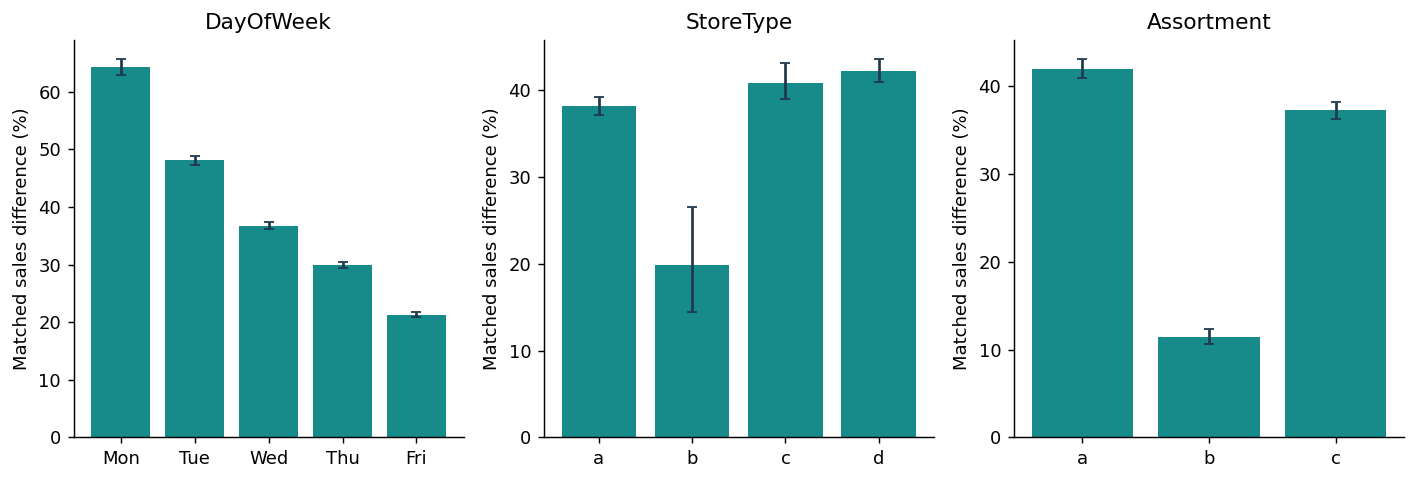

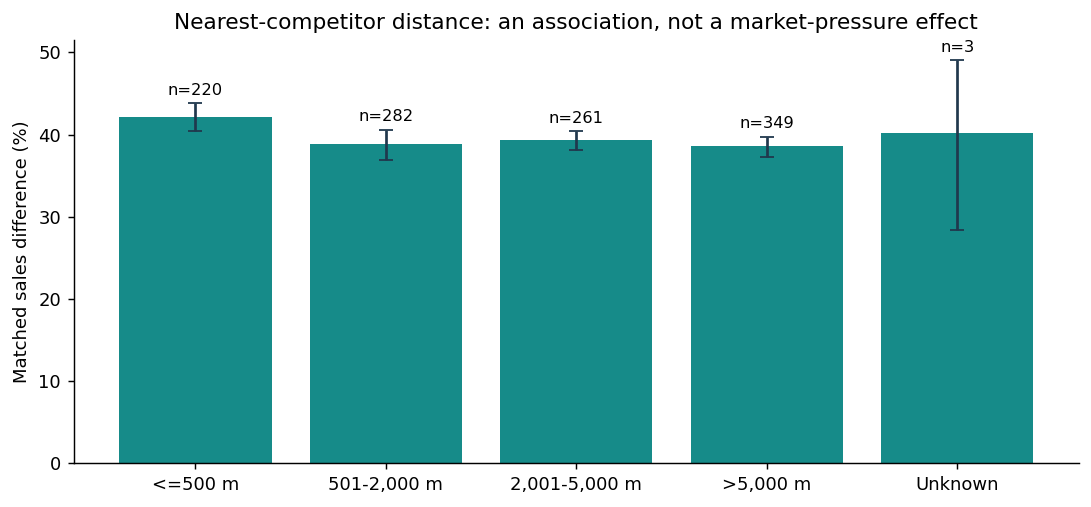

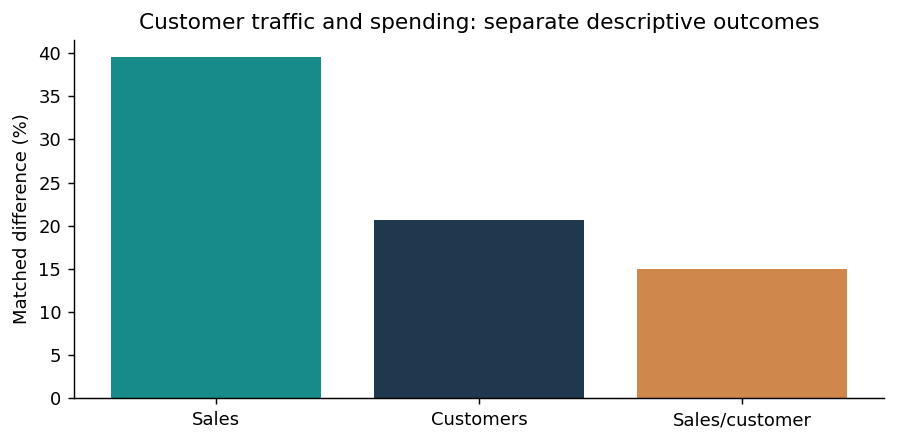

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, group in zip(axes, ['DayOfWeek', 'StoreType', 'Assortment']):
    s = segments[group].query("outcome == 'Sales'")
    labels = s['group'].replace({'1': 'Mon', '2': 'Tue', '3': 'Wed', '4': 'Thu', '5': 'Fri'}) if group == 'DayOfWeek' else s['group']
    ax.bar(labels, s.lift_pct, color=COLORS[1])
    ax.errorbar(range(len(s)), s.lift_pct, yerr=[s.lift_pct - s.lower, s.upper - s.lift_pct], fmt='none', color=COLORS[0], capsize=3)
    ax.set_title(group); ax.set_ylabel('Matched sales difference (%)')
savefig('02_matched_conditions')
s = segments['CompetitionBand'].query("outcome == 'Sales'").set_index('group').reindex(['<=500 m', '501-2,000 m', '2,001-5,000 m', '>5,000 m', 'Unknown']).dropna()
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(s.index, s.lift_pct, color=COLORS[1])
ax.errorbar(range(len(s)), s.lift_pct, yerr=[s.lift_pct - s.lower, s.upper - s.lift_pct], fmt='none', color=COLORS[0], capsize=4)
for i, (_, row) in enumerate(s.iterrows()):
    ax.text(i, row.upper + 1, 'n=' + str(int(row.stores)), ha='center', fontsize=9)
ax.set_ylabel('Matched sales difference (%)'); ax.set_title('Nearest-competitor distance: an association, not a market-pressure effect')
savefig('03_competition')
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(['Sales', 'Customers', 'Sales/customer'], overall.lift_pct, color=[COLORS[1], COLORS[0], COLORS[2]])
ax.set_ylabel('Matched difference (%)'); ax.set_title('Customer traffic and spending: separate descriptive outcomes')
savefig('04_mechanism')

## 5. Prepare features without future outcomes

Use 2013 only to calculate a fixed store sales baseline. Forecasting models are trained from 2014 onward; no 2014-2015 sales enter this baseline. Current-day customers and sales/customer are excluded from the predictors because they are outcomes of the same day and may themselves respond to promotion.

Store type, assortment and weekday are categorical. Calendar dates, school holidays and store metadata are available before the sales outcome. `Promo2Scheduled` is a date-derived proxy for the published recurring program, not proof a specific offer ran. Unknown opening dates remain unknown; elapsed competitor age is only defined after the recorded opening month. Distance metadata may represent the data collection snapshot rather than historical distance.

In [6]:
history = d.loc[d.Year.eq(2013)]
store_baseline = history.groupby('Store').Sales.mean()
f = d.loc[d.Year.ge(2014)].copy()
f['HistoricalSales'] = f.Store.map(store_baseline)
assert f.HistoricalSales.notna().all()
f['TimeIndex'] = (f.Date - pd.Timestamp('2014-01-01')).dt.days
f['DayOfMonth'] = f.Date.dt.day
f['LogCompetitionDistance'] = np.log1p(f.CompetitionDistance)
known = f.CompetitionOpenSinceYear.notna() & f.CompetitionOpenSinceMonth.notna()
opening = pd.to_datetime({'year': f.CompetitionOpenSinceYear, 'month': f.CompetitionOpenSinceMonth, 'day': np.ones(len(f))}, errors='coerce')
months = (f.Date.dt.year - opening.dt.year) * 12 + f.Date.dt.month - opening.dt.month
f['CompetitionAgeMonths'] = months.where(known & months.ge(0))
f['CompetitionDateKnown'] = known.astype(int)
f['CompetitionRecordedOpen'] = (known & months.ge(0)).astype(int)
start_text = f.Promo2SinceYear.fillna(2000).astype(int).astype(str) + '-W' + f.Promo2SinceWeek.fillna(1).astype(int).astype(str).str.zfill(2) + '-1'
program_start = pd.to_datetime(start_text, format='%G-W%V-%u', errors='coerce')
month_names = f.Date.dt.strftime('%b').replace({'Sep': 'Sept'})
scheduled = [month in str(interval).split(',') for month, interval in zip(month_names, f.PromoInterval)]
f['Promo2Scheduled'] = (f.Promo2.eq(1) & f.Date.ge(program_start) & np.array(scheduled)).astype(int)
CATS = ['StoreType', 'Assortment', 'DayOfWeek', 'Month']
NUMS = ['Promo', 'HistoricalSales', 'TimeIndex', 'DayOfMonth', 'SchoolHoliday', 'LogCompetitionDistance', 'CompetitionAgeMonths', 'CompetitionDateKnown', 'CompetitionRecordedOpen', 'Promo2', 'Promo2Scheduled']
FEATURES = CATS + NUMS
for c in CATS:
    f[c] = f[c].astype('category')
fit = f.Date.lt('2015-04-01')
validation = f.Date.between('2015-04-01', '2015-05-31')
test = f.Date.ge('2015-06-01')
table(pd.DataFrame([{'split': name, 'rows': int(mask.sum()), 'start': str(f.loc[mask, 'Date'].min().date()), 'end': str(f.loc[mask, 'Date'].max().date())} for name, mask in [('train', fit), ('validation', validation), ('test', test)]]), 'time_splits')
assert f.loc[fit].Date.max() < f.loc[validation].Date.min() < f.loc[test].Date.min()

     split   rows      start        end
     train 325718 2014-01-02 2015-03-31
validation  42353 2015-04-01 2015-05-29
      test  49355 2015-06-01 2015-07-31


## 6. A readable baseline and a nonlinear benchmark

Ridge regression uses one-hot store identifiers and calendar categories, plus promo-by-weekday interactions. A histogram gradient boosting model captures nonlinear relationships with no extra boosting dependency. It uses the 2013 store baseline rather than treating the arbitrary store ID as a numeric feature.

Fit two modest tree sizes on the training period and select by validation MAE. Refit the chosen design through May 2015 and evaluate once on June-July. No random split and no tuning on the final test period. The linear model has an explicit promo-weekday term; its percentage scenario difference can also vary with baseline sales.

In [7]:
base_cats = ['Store', 'YearMonth', 'DayOfWeek', 'Month', 'StoreType', 'Assortment']
base_nums = NUMS + ['PromoMon', 'PromoTue', 'PromoWed', 'PromoThu']
for day, name in enumerate(['PromoMon', 'PromoTue', 'PromoWed', 'PromoThu'], start=1):
    f[name] = f.Promo * f.DayOfWeek.astype(int).eq(day).astype(int)
base_features = base_cats + base_nums
baseline = make_pipeline(ColumnTransformer([('cats', OneHotEncoder(handle_unknown='ignore'), base_cats), ('nums', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), base_nums)]), Ridge(alpha=100, solver='lsqr'))
baseline.fit(f.loc[fit, base_features], f.loc[fit, 'Sales'])
choices = []
for leaves in [15, 31]:
    candidate = HistGradientBoostingRegressor(max_leaf_nodes=leaves, max_iter=180, learning_rate=.08, min_samples_leaf=100, l2_regularization=10, categorical_features='from_dtype', early_stopping=False, random_state=SEED)
    candidate.fit(f.loc[fit, FEATURES], f.loc[fit, 'Sales'])
    choices.append({'leaves': leaves, 'validation_mae': mean_absolute_error(f.loc[validation, 'Sales'], candidate.predict(f.loc[validation, FEATURES]))})
tuning = pd.DataFrame(choices)
table(tuning, 'validation_selection')
best_leaves = int(tuning.sort_values('validation_mae').iloc[0].leaves)
model = HistGradientBoostingRegressor(max_leaf_nodes=best_leaves, max_iter=180, learning_rate=.08, min_samples_leaf=100, l2_regularization=10, categorical_features='from_dtype', early_stopping=False, random_state=SEED)
refit = fit | validation
model.fit(f.loc[refit, FEATURES], f.loc[refit, 'Sales'])
baseline.fit(f.loc[refit, base_features], f.loc[refit, 'Sales'])
metrics = []
for name, estimator, columns in [('Ridge', baseline, base_features), ('Histogram boosting', model, FEATURES)]:
    pred = estimator.predict(f.loc[test, columns])
    metrics.append({'model': name, 'MAE': mean_absolute_error(f.loc[test, 'Sales'], pred), 'RMSE': np.sqrt(mean_squared_error(f.loc[test, 'Sales'], pred)), 'R2': r2_score(f.loc[test, 'Sales'], pred)})
metrics = pd.DataFrame(metrics)
table(metrics, 'test_metrics')
test_observed = f.loc[test, ['Store', 'Date', 'Promo', 'Sales']].copy()
test_observed['Prediction'] = model.predict(f.loc[test, FEATURES])
test_observed['AbsError'] = abs(test_observed.Sales - test_observed.Prediction)
table(test_observed.groupby('Promo').agg(rows=('Sales', 'size'), MAE=('AbsError', 'mean')).reset_index(), 'test_metrics_by_promo')
test_observed.to_csv(OUT / 'results' / 'test_predictions.csv', index=False)

 leaves  validation_mae
     15        1121.410
     31         935.883
             model     MAE     RMSE    R2
             Ridge 858.954 1196.185 0.850
Histogram boosting 797.659 1095.346 0.874
 Promo  rows     MAE
     0 22280 645.399
     1 27075 922.953


## 7. Scenario contrasts on the held-out period

Copy each eligible June-July store-day twice. Change Promo to 0 and 1 while keeping other pre-outcome predictors fixed. The difference is a **model-implied scenario contrast**. It does not identify what would truly have happened under the other status: unobserved calendar shocks and promotion selection remain.

Summaries average equally within store and then over stores. Tree-model scenario contrasts are descriptive complements to matching, not a promotion decision rule. Validation accuracy checks sales prediction, not the accuracy of an unobserved counterfactual.

Nonpositive Ridge no-promo predictions: 0
DayOfWeek  boosting_pct  ridge_pct  stores
        1        54.428     67.397    1115
        2        36.987     47.349    1115
        3        31.086     46.718    1115
        4        31.967     37.757    1115
        5        23.670     22.794    1115
StoreType  boosting_pct  ridge_pct  stores
        a        35.240     44.791     602
        b        21.821     32.735      17
        c        35.767     45.705     148
        d        37.098     44.085     348
Assortment  boosting_pct  ridge_pct  stores
         a        37.926     47.059     593
         b        15.875     39.110       9
         c        33.443     41.656     513
CompetitionBand  boosting_pct  ridge_pct  stores
  2,001-5,000 m        35.551     45.073     261
    501-2,000 m        34.955     46.331     282
        <=500 m        37.100     42.236     220
       >5,000 m        35.486     43.911     349
        Unknown        35.542     60.223       3


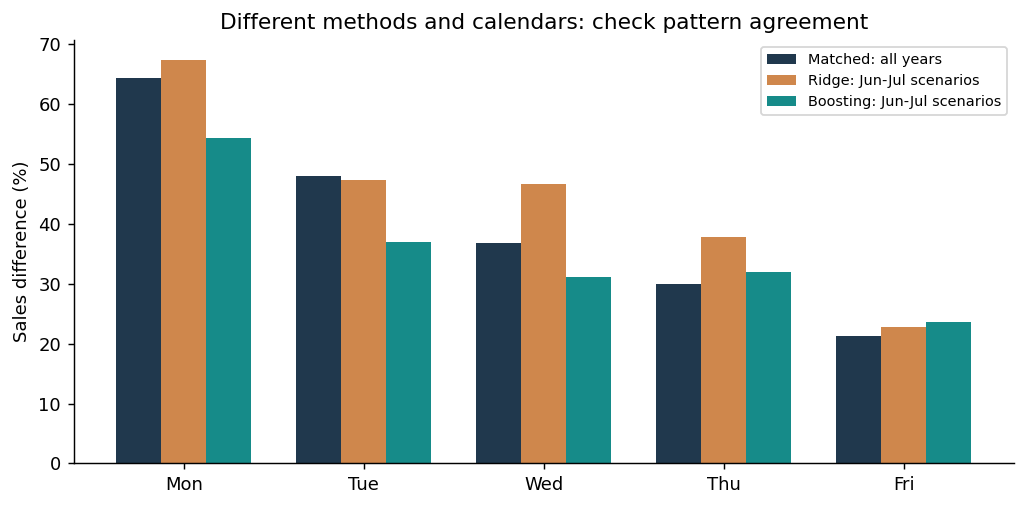

In [8]:
held = f.loc[test].copy()
x0, x1 = held[FEATURES].copy(), held[FEATURES].copy()
x0['Promo'], x1['Promo'] = 0, 1
held['PredNoPromo'] = model.predict(x0)
held['PredPromo'] = model.predict(x1)
held['ScenarioLiftPct'] = 100 * (held.PredPromo - held.PredNoPromo) / held.PredNoPromo
assert held.PredNoPromo.gt(0).all()
b0, b1 = held[base_features].copy(), held[base_features].copy()
for status, xx in [(0, b0), (1, b1)]:
    xx['Promo'] = status
    for day, name in enumerate(['PromoMon', 'PromoTue', 'PromoWed', 'PromoThu'], start=1):
        xx[name] = status * xx.DayOfWeek.astype(int).eq(day).astype(int)
bp0, bp1 = baseline.predict(b0), baseline.predict(b1)
held['RidgeScenarioLiftPct'] = 100 * (bp1 - bp0) / bp0
print('Nonpositive Ridge no-promo predictions:', int((bp0 <= 0).sum()))
def scenario_summary(frame, group):
    s = frame.groupby([group, 'Store'], observed=True)[['ScenarioLiftPct', 'RidgeScenarioLiftPct']].mean()
    return s.groupby(level=0, observed=True).agg(boosting_pct=('ScenarioLiftPct', 'mean'), ridge_pct=('RidgeScenarioLiftPct', 'mean'), stores=('ScenarioLiftPct', 'size')).reset_index()
scenario = {}
for group in ['DayOfWeek', 'StoreType', 'Assortment', 'CompetitionBand']:
    scenario[group] = scenario_summary(held, group)
    table(scenario[group], 'scenario_' + group)
held[['Store', 'Date', 'Promo', 'PredNoPromo', 'PredPromo', 'ScenarioLiftPct', 'RidgeScenarioLiftPct']].to_csv(OUT / 'results' / 'scenario_rows.csv', index=False)
fig, ax = plt.subplots(figsize=(8, 4))
s = scenario['DayOfWeek']
x = np.arange(len(s)); w = .25
matched_weekday = segments['DayOfWeek'].query("outcome == 'Sales'").set_index('group')
ax.bar(x-w, [matched_weekday.loc[str(int(day)), 'lift_pct'] for day in s.DayOfWeek], w, label='Matched: all years', color=COLORS[0])
ax.bar(x, s.ridge_pct, w, label='Ridge: Jun-Jul scenarios', color=COLORS[2])
ax.bar(x+w, s.boosting_pct, w, label='Boosting: Jun-Jul scenarios', color=COLORS[1])
ax.set_xticks(x, ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']); ax.set_ylabel('Sales difference (%)'); ax.set_title('Different methods and calendars: check pattern agreement'); ax.legend(fontsize=8)
savefig('05_methods_weekday')

## 8. Explain prediction and challenge the findings

Permutation importance measures how much shuffling a feature worsens held-out prediction. It is not a measure of causal contribution or of the promotion interaction. Correlated features can share importance.

Robustness checks change the calendar, remove the largest 1% of observed sales, require five total days while retaining two per status, and restrict competition comparisons to stores whose recorded competitor opening predates 2013. The latter is still a restricted snapshot-based comparison, not a historical competitor-location panel.

                feature  increase_MAE     sd
        HistoricalSales      1833.280  3.803
                  Promo       728.440 15.553
              DayOfWeek       203.856  4.676
             DayOfMonth       107.574  2.804
   CompetitionAgeMonths        63.500  0.611
 LogCompetitionDistance        56.163  2.626
             Assortment        53.526  1.939
                  Month        49.974  0.671
              StoreType        32.489  0.341
          SchoolHoliday        16.070  0.907
                 Promo2        13.518  0.319
        Promo2Scheduled         9.767  1.475
   CompetitionDateKnown         0.456  0.070
              TimeIndex         0.000  0.000
CompetitionRecordedOpen         0.000  0.000
                check  stores  lift_pct
                 2013    1115    37.845
                 2014    1115    42.083
         2015 Jan-Jul    1115    38.755
At least 5 total days    1115    44.653
 Exclude top 1% sales    1114    39.219
 Year  DayOfWeek  SalesLiftPct
 2013    

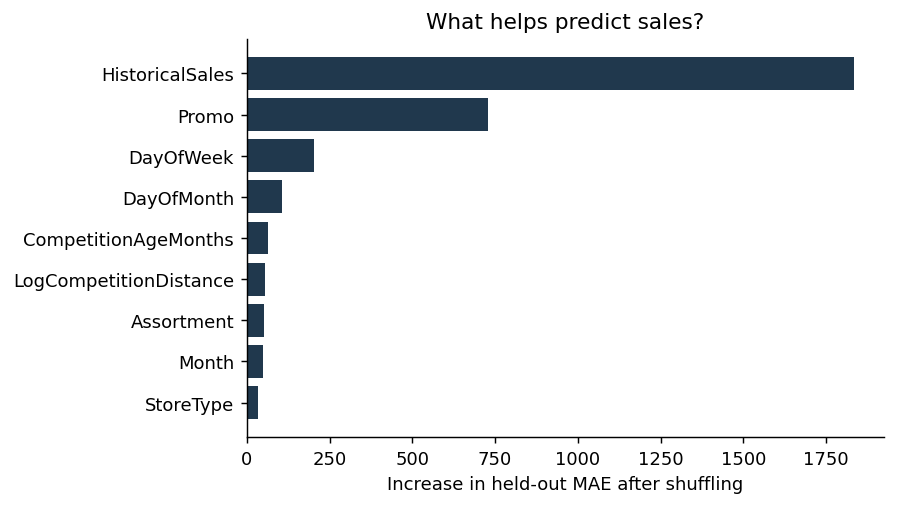

In [9]:
sample = held.sample(n=min(6000, len(held)), random_state=SEED)
importance = permutation_importance(model, sample[FEATURES], sample.Sales, n_repeats=3, random_state=SEED, scoring='neg_mean_absolute_error', n_jobs=1)
imp = pd.DataFrame({'feature': FEATURES, 'increase_MAE': importance.importances_mean, 'sd': importance.importances_std}).sort_values('increase_MAE', ascending=False)
table(imp, 'permutation_importance')
fig, ax = plt.subplots(figsize=(7, 4))
p = imp.head(9).sort_values('increase_MAE')
ax.barh(p.feature, p.increase_MAE, color=COLORS[0]); ax.set_xlabel('Increase in held-out MAE after shuffling'); ax.set_title('What helps predict sales?')
savefig('06_importance')
robustness = []
for label, part in [('2013', matched.query('Year == 2013')), ('2014', matched.query('Year == 2014')), ('2015 Jan-Jul', matched.query('Year == 2015')), ('At least 5 total days', matched.merge(n.loc[n[0].ge(2) & n[1].ge(2) & n.sum(axis=1).ge(5)].index.to_frame(index=False), on=keys))]:
    s = summarize_matches(part).query("outcome == 'Sales'").iloc[0]
    robustness.append({'check': label, 'stores': s.stores, 'lift_pct': s.lift_pct})
trim = d.loc[d.Sales.le(d.Sales.quantile(.99))]
tg = trim.groupby(keys + ['Promo']).Sales.mean().unstack('Promo')
tn = trim.groupby(keys + ['Promo']).size().unstack('Promo', fill_value=0)
tg = tg.loc[tn[0].ge(2) & tn[1].ge(2)]
trim_pairs = tg.index.to_frame(index=False)
trim_pairs['SalesLiftPct'] = (100 * (tg[1] / tg[0] - 1)).to_numpy()
robustness.append({'check': 'Exclude top 1% sales', 'stores': trim_pairs.Store.nunique(), 'lift_pct': trim_pairs.groupby('Store').SalesLiftPct.mean().mean()})
robustness = pd.DataFrame(robustness)
table(robustness, 'robustness')
by_year_day = matched.groupby(['Year', 'DayOfWeek', 'Store']).SalesLiftPct.mean().groupby(['Year', 'DayOfWeek']).mean().reset_index()
table(by_year_day, 'weekday_by_year')
restricted = matched.loc[matched.CompetitionOpenSinceYear.lt(2013)]
table(summarize_matches(restricted, 'CompetitionBand'), 'competition_pre2013')
within_format = matched.groupby(['StoreType', 'CompetitionBand', 'Store']).SalesLiftPct.mean().groupby(['StoreType', 'CompetitionBand']).agg(lift_pct='mean', stores='size').reset_index()
table(within_format, 'competition_within_format')
month_sensitivity = pd.DataFrame([{'excluded_month': month, 'lift_pct': matched.loc[matched.Month.ne(month)].groupby('Store').SalesLiftPct.mean().mean()} for month in range(1, 13)])
table(month_sensitivity, 'leave_one_month_out')
(OUT / 'results' / 'audit.json').write_text(json.dumps(audit, indent=2))
print('All results and figures saved under', OUT)

## 9. How to use these results

Read `matched_overall.csv`, `matched_DayOfWeek.csv`, `scenario_DayOfWeek.csv` and `robustness.csv` together. Prefer patterns that recur across calendar periods and model specifications. Treat finer store and proximity rankings as hypotheses for controlled tests.

A useful next business step is a randomized store-week pilot stratified by format and proximity, with sales, margin, offer cost and post-promotion sales measured. This project does not estimate net profit, long-run demand, promotion fatigue, optimal discount depth or a causal return on promotion.

**Sources:** [Rossmann competition and data dictionary](https://www.kaggle.com/competitions/rossmann-store-sales/data); [scikit-learn histogram boosting documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html). All numerical results come from the supplied files. No generated or manually filled data are used.